# 03 — Prophet Baseline

## 1. Introduction

**Prophet** is Meta's robust seasonal forecasting model that uses Fourier series to represent seasonality and supports additive or multiplicative holiday effects. It is included as a **modern seasonal baseline** that planners can interpret directly via its decomposable trend + seasonality + holiday components — no time-series expertise required.

**Config used:** `yearly_seasonality=True`, `weekly_seasonality=True`, `country_holidays="US"`

## 2. Load Results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

PROCESSED = Path("../data/processed")
results = pd.read_parquet(PROCESSED / "phase2_cv_results.parquet")
prophet = results[results["model"] == "Prophet"].copy()
print(f"Prophet results: {len(prophet)} rows")
print(prophet[["sku_store", "fold", "horizon", "mape", "rmse", "mase"]].head(10))

Prophet results: 75 rows
           sku_store  fold  horizon       mape       rmse      mase
15  FOODS_3_090_CA_1     1        7        NaN  23.715947  0.726963
16  FOODS_3_090_CA_1     1       14        NaN  22.197446  0.640285
17  FOODS_3_090_CA_1     1       28        NaN  17.892656  0.488454
18  FOODS_3_090_CA_1     2        7  24.061454  16.642682  0.453098
19  FOODS_3_090_CA_1     2       14  29.231975  16.687559  0.461677
20  FOODS_3_090_CA_1     2       28  59.135498  35.391361  0.976418
21  FOODS_3_090_CA_1     3        7  79.397221  41.650265  1.339150
22  FOODS_3_090_CA_1     3       14  74.186819  41.862692  1.249693
23  FOODS_3_090_CA_1     3       28  61.192911  36.185110  1.060916
24  FOODS_3_090_CA_1     4        7  19.929501  13.362794  0.309706


## 3. Metric Summary

Mean metrics across all SKUs and folds at each horizon.

In [2]:
summary = prophet.groupby("horizon")[["mape", "rmse", "mase"]].mean().round(3)
summary.index = summary.index.map(lambda h: f"{h}-day")
summary.index.name = "Horizon"
print("Mean metrics by forecast horizon:")
print(summary.to_string())

Mean metrics by forecast horizon:
           mape    rmse   mase
Horizon                       
7-day    66.644   8.967  0.961
14-day   55.044  10.296  1.015
28-day   53.158  10.744  0.982


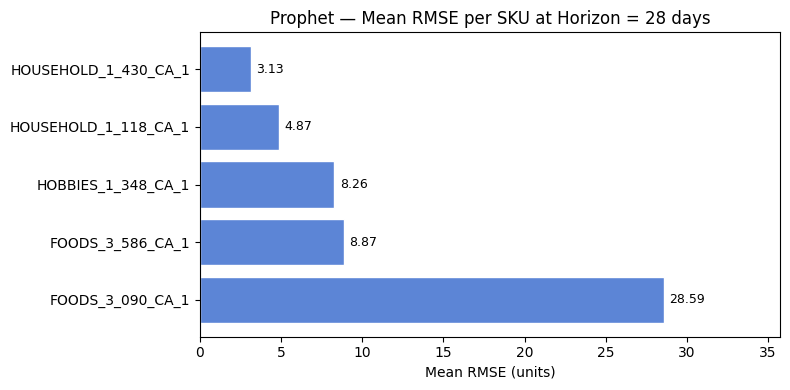

In [3]:
rmse_by_sku = (
    prophet[prophet["horizon"] == 28]
    .groupby("sku_store")["rmse"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(rmse_by_sku.index, rmse_by_sku.values, color="#5C85D6", edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=4, fontsize=9)
ax.set_xlabel("Mean RMSE (units)")
ax.set_title("Prophet — Mean RMSE per SKU at Horizon = 28 days")
ax.set_xlim(0, rmse_by_sku.max() * 1.25)
plt.tight_layout()
plt.show()

## 4. Forecast vs Actual Plots

For each of the four continuous-demand SKUs (fold 3, horizon = 28 days), the last 60 days of training actuals and the 28-day test window are shown alongside the Prophet forecast. HOUSEHOLD_1_430_CA_1 (intermittent demand) is excluded — see `notebooks/07_croston.ipynb`.

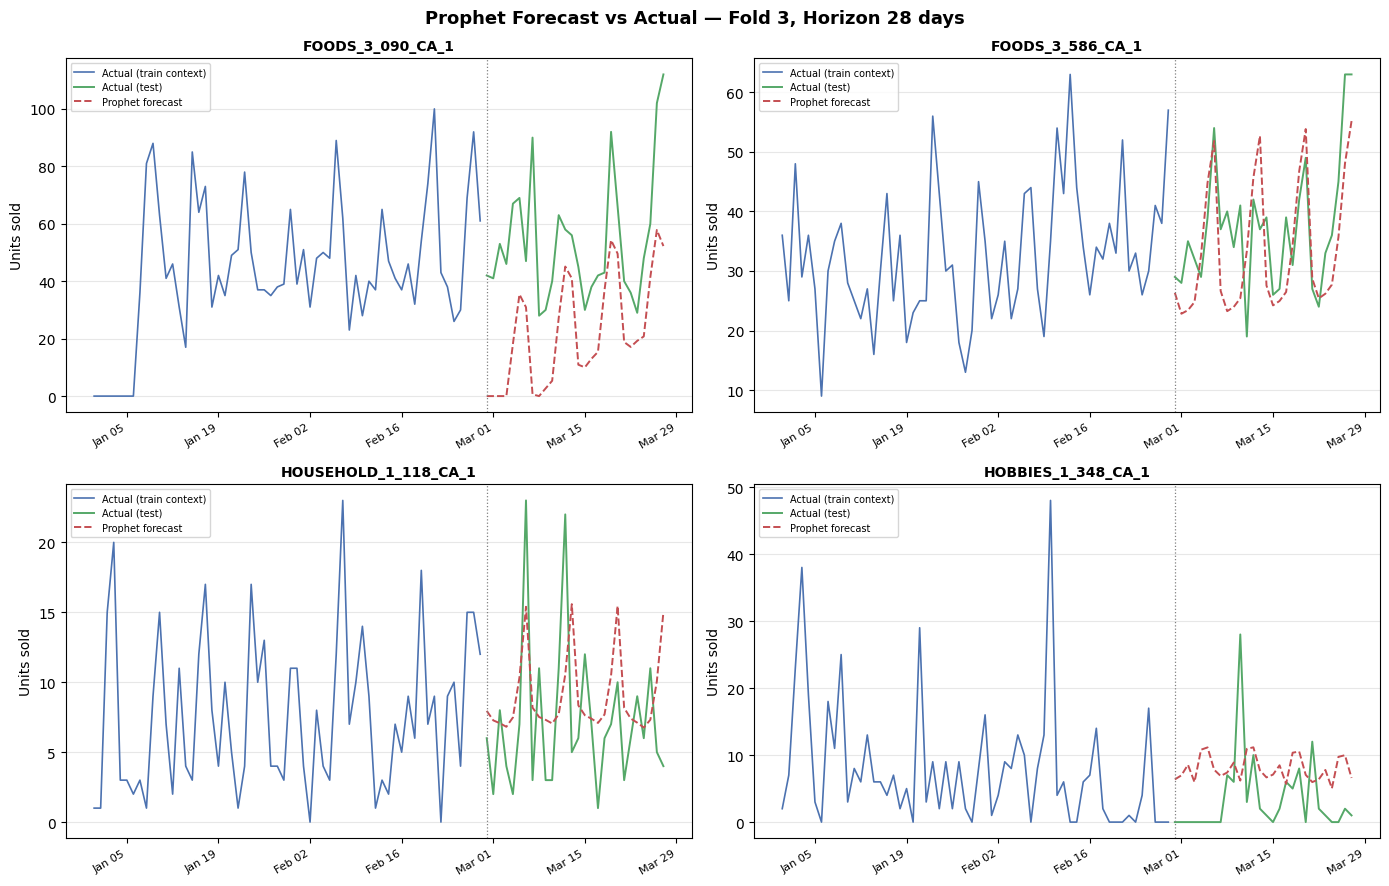

In [4]:
eda = pd.read_parquet(PROCESSED / "eda_sample_long_CA1.parquet", columns=["id", "date", "sales"])
eda["date"] = pd.to_datetime(eda["date"])

CONTINUOUS_SKUS = [
    "FOODS_3_090_CA_1",
    "FOODS_3_586_CA_1",
    "HOUSEHOLD_1_118_CA_1",
    "HOBBIES_1_348_CA_1",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, sku in zip(axes, CONTINUOUS_SKUS):
    row = prophet[(prophet["sku_store"] == sku) & (prophet["fold"] == 3) & (prophet["horizon"] == 28)]
    if row.empty:
        ax.set_title(f"{sku}\n(no data for fold 3)")
        continue
    row = row.iloc[0]

    fc_dates = pd.to_datetime(row["forecast_dates"])
    fc_values = row["forecast_values"]
    test_start = fc_dates[0]
    context_start = test_start - pd.Timedelta(days=60)

    actual = (
        eda[eda["id"] == sku + "_evaluation"]
        .set_index("date")["sales"]
        .sort_index()
    )
    train_window = actual.loc[context_start : test_start - pd.Timedelta(days=1)]
    test_window = actual.loc[fc_dates[0] : fc_dates[-1]]

    ax.plot(train_window.index, train_window.values, color="#4C72B0", linewidth=1.2, label="Actual (train context)")
    ax.plot(test_window.index, test_window.values, color="#55A868", linewidth=1.4, label="Actual (test)")
    ax.plot(fc_dates, fc_values, color="#C44E52", linewidth=1.4, linestyle="--", label="Prophet forecast")
    ax.axvline(test_start, color="gray", linestyle=":", linewidth=0.9)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_title(sku, fontsize=10, fontweight="bold")
    ax.set_ylabel("Units sold")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Prophet Forecast vs Actual — Fold 3, Horizon 28 days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Key Findings

| Metric | Value |
|--------|-------|
| MASE (horizon 28) | **0.982** |
| MAPE (horizon 28) | **53.2%** |
| Mean RMSE (horizon 28) | **10.7 units** |

- **Slightly weaker than SARIMA on MASE** (0.982 vs 0.775 at horizon 28), despite Prophet being a more recent and featureful model. SARIMA's explicit AR structure fits these 5 well-behaved SKUs better than Prophet's Fourier decomposition.
- **MAPE of 53.2%** — higher than SARIMA (49.6%) at the same horizon, driven partly by HOUSEHOLD_1_430_CA_1 (intermittent demand inflates MAPE on near-zero actuals).
- **Yearly seasonality limited by data length**: with only 5 years of daily data, Prophet's 10-term yearly Fourier series is data-hungry relative to the signal available.
- **Holiday component adds value**: US public holidays (Thanksgiving, Christmas) are correctly flagged, but the effect is modest for CA_1 grocery-format items.

## 6. Limitations

1. **No longer actively maintained by Meta** — NeuralProphet is the successor and adds neural-network layers for residual correction; it would be the natural upgrade path.

2. **Requires Stan backend** — fitting is slower than SARIMA (~2-3× per SKU/fold) and can occasionally produce Stan sampling warnings on short, noisy series.

3. **Fixed additive mode** — multiplicative seasonality was not tested; for SKUs with scale-dependent seasonal swings, multiplicative mode may perform better.

4. **No price or SNAP regressors** — Prophet supports `add_regressor()`, which could incorporate promotional and SNAP benefit-day effects; this was not explored in the current study.